In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [3]:
df = pd.read_csv(r"C:\Users\NIKHIL JAISWAL\Music\Loan-Approval-Analysis\Loan-Approval-Analysis\10_loan_approval.csv")
df.head()

,age,income_lakh,credit_score,loan_amount_lakh,existing_loans,approved
0,28.0,12.64,613.0,8.93,3.0,1
1,57.0,19.80,753.0,28.22,3.0,1
2,35.0,20.54,787.0,18.94,1.0,1
3,59.0,18.87,816.0,11.61,1.0,1
4,62.0,11.63,553.0,5.23,3.0,1


In [4]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
display(df.describe())

Shape: (1020, 6)

Columns:
['age', 'income_lakh', 'credit_score', 'loan_amount_lakh', 'existing_loans', 'approved']

Data Types:
age                 float64
income_lakh         float64
credit_score        float64
loan_amount_lakh    float64
existing_loans      float64
approved              int64
dtype: object

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               1009 non-null   float64
 1   income_lakh       1010 non-null   float64
 2   credit_score      1010 non-null   float64
 3   loan_amount_lakh  1010 non-null   float64
 4   existing_loans    1010 non-null   float64
 5   approved          1020 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 47.9 KB

Statistical Summary:


,age,income_lakh,credit_score,loan_amount_lakh,existing_loans,approved
count,1009.000000,1010.000000,1010.000000,1010.000000,1010.000000,1020.000000
mean,42.448959,13.453802,644.527723,15.857168,2.048515,0.664706
std,12.753447,6.949768,119.393453,8.273434,1.423512,0.472325
min,15.000000,-5.000000,450.000000,1.040000,-2.000000,0.000000
25%,31.000000,7.372500,539.000000,8.995000,1.000000,0.000000
50%,42.000000,13.765000,643.000000,15.860000,2.000000,1.000000
75%,53.000000,19.387500,744.750000,22.900000,3.000000,1.000000
max,64.000000,24.990000,1000.000000,29.960000,4.000000,1.000000


In [5]:
missing_values = df.isnull().sum()

print("Missing values:")
print(missing_values)

Missing values:
age                 11
income_lakh         10
credit_score        10
loan_amount_lakh    10
existing_loans      10
approved             0
dtype: int64


In [6]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 20


In [7]:
invalid_age = df[(df["age"] < 18) | (df["age"] > 100)]

print("Number of unrealistic ages:", len(invalid_age))
display(invalid_age)

Number of unrealistic ages: 5


,age,income_lakh,credit_score,loan_amount_lakh,existing_loans,approved
123,15.0,10.15,529.0,22.10,1.0,0
170,15.0,19.44,753.0,24.54,4.0,1
266,15.0,19.45,831.0,27.44,3.0,1
523,15.0,3.52,624.0,17.86,4.0,0
555,15.0,10.64,710.0,18.01,4.0,0


In [8]:
invalid_credit = df[
    (df["credit_score"] < 300) |
    (df["credit_score"] > 850)
]

print("Number of invalid credit scores:", len(invalid_credit))
display(invalid_credit)

Number of invalid credit scores: 5


,age,income_lakh,credit_score,loan_amount_lakh,existing_loans,approved
21,48.0,13.17,1000.0,19.20,2.0,1
80,31.0,8.47,1000.0,10.37,2.0,1
225,51.0,22.82,1000.0,24.86,3.0,1
976,48.0,6.57,1000.0,8.04,2.0,1
1003,37.0,16.82,1000.0,25.15,2.0,1


In [9]:
negative_income = df[df["income_lakh"] < 0]

print("Number of negative income values:", len(negative_income))
display(negative_income)

Number of negative income values: 5


,age,income_lakh,credit_score,loan_amount_lakh,existing_loans,approved
20,39.0,-5.0,584.0,21.52,2.0,1
210,60.0,-5.0,476.0,17.56,1.0,1
565,47.0,-5.0,476.0,29.76,1.0,0
739,62.0,-5.0,687.0,6.70,1.0,1
812,31.0,-5.0,822.0,9.01,1.0,1


In [11]:
negative_loans = df[df["existing_loans"] < 0]

print("Number of negative existing loans:", len(negative_loans))
display(negative_loans)
negative_loan_amount = df[df["loan_amount_lakh"] < 0]

print("Negative loan amounts:", len(negative_loan_amount))

Number of negative existing loans: 5


,age,income_lakh,credit_score,loan_amount_lakh,existing_loans,approved
344,34.0,17.10,611.0,12.59,-2.0,1
500,36.0,19.08,490.0,25.68,-2.0,1
573,43.0,11.64,730.0,8.50,-2.0,1
821,35.0,17.91,538.0,5.98,-2.0,1
885,25.0,17.39,746.0,27.63,-2.0,1


Negative loan amounts: 0


approved
1    678
0    342
Name: count, dtype: int64


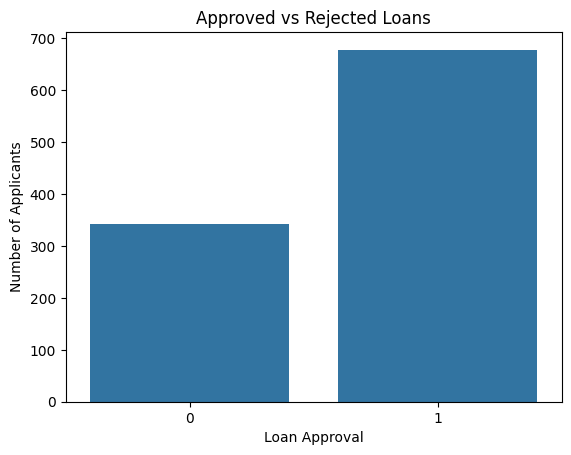

In [12]:
print(df["approved"].value_counts())
sns.countplot(data=df, x="approved")

plt.title("Approved vs Rejected Loans")
plt.xlabel("Loan Approval")
plt.ylabel("Number of Applicants")
plt.show()

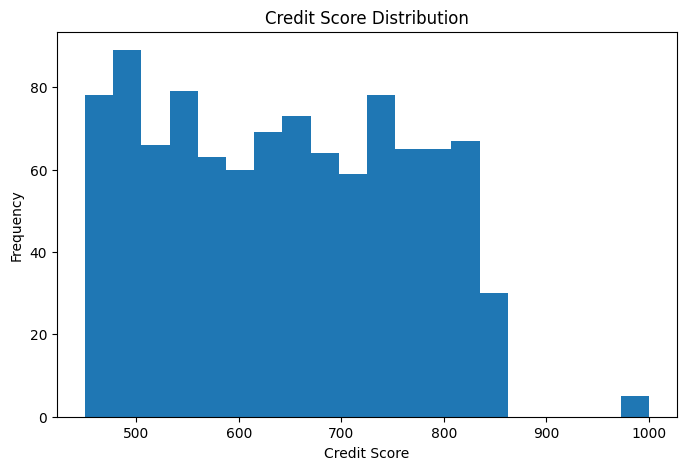

In [13]:
plt.figure(figsize=(8, 5))

plt.hist(df["credit_score"].dropna(), bins=20)

plt.title("Credit Score Distribution")
plt.xlabel("Credit Score")
plt.ylabel("Frequency")

plt.show()

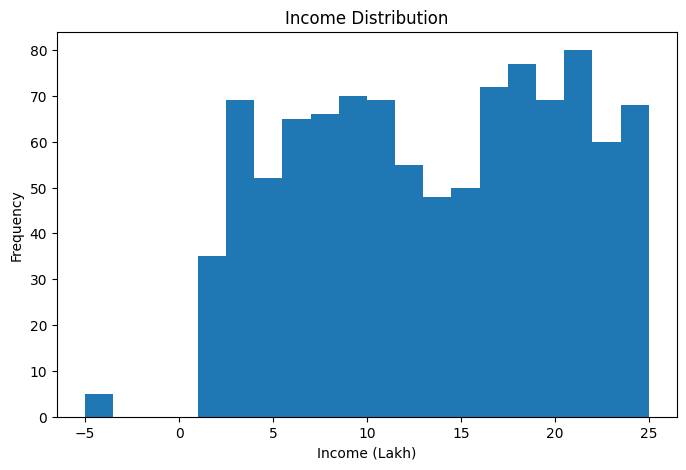

In [14]:
plt.figure(figsize=(8, 5))

plt.hist(df["income_lakh"].dropna(), bins=20)

plt.title("Income Distribution")
plt.xlabel("Income (Lakh)")
plt.ylabel("Frequency")

plt.show()

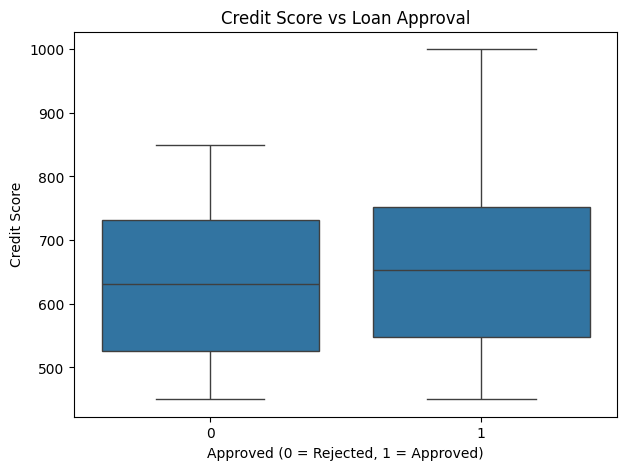

In [15]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="approved",
    y="credit_score"
)

plt.title("Credit Score vs Loan Approval")
plt.xlabel("Approved (0 = Rejected, 1 = Approved)")
plt.ylabel("Credit Score")

plt.show()

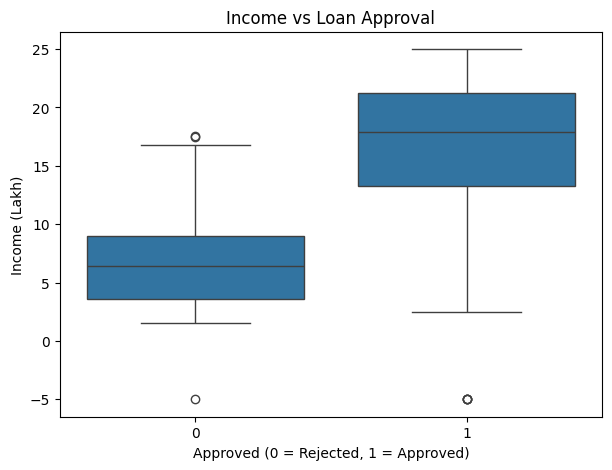

In [16]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="approved",
    y="income_lakh"
)

plt.title("Income vs Loan Approval")
plt.xlabel("Approved (0 = Rejected, 1 = Approved)")
plt.ylabel("Income (Lakh)")

plt.show()

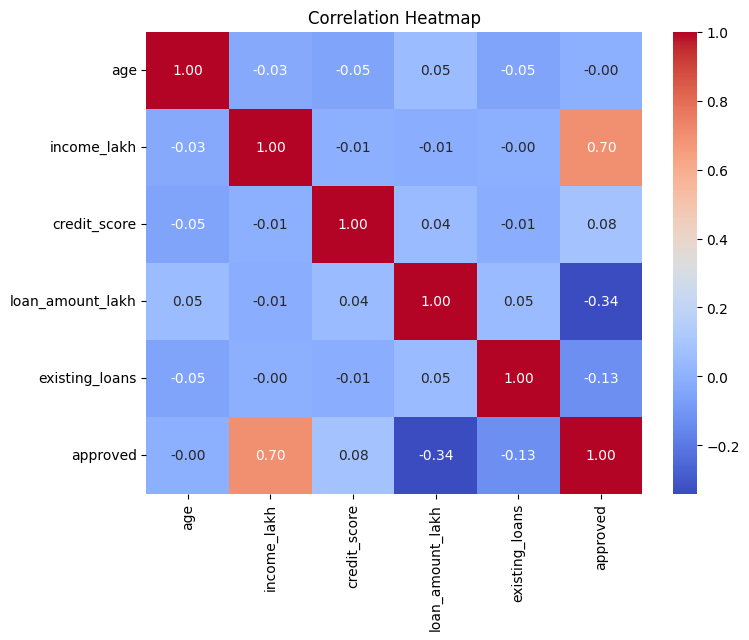

In [17]:
plt.figure(figsize=(8, 6))

correlation = df.corr(numeric_only=True)

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

In [20]:
clean_df = df.copy()
clean_df = clean_df.drop_duplicates()

print("Shape after removing duplicates:", clean_df.shape)
# Invalid ages
clean_df.loc[
    (clean_df["age"] < 18) | (clean_df["age"] > 100),
    "age"
] = np.nan

# Invalid credit scores
clean_df.loc[
    (clean_df["credit_score"] < 300) |
    (clean_df["credit_score"] > 850),
    "credit_score"
] = np.nan

# Negative income
clean_df.loc[
    clean_df["income_lakh"] < 0,
    "income_lakh"
] = np.nan

# Negative existing loans
clean_df.loc[
    clean_df["existing_loans"] < 0,
    "existing_loans"
] = np.nan

numeric_columns = [
    "age",
    "income_lakh",
    "credit_score",
    "loan_amount_lakh",
    "existing_loans"
]

for col in numeric_columns:
    clean_df[col] = clean_df[col].fillna(clean_df[col].median())
print(clean_df.isnull().sum())
print("Duplicates:", clean_df.duplicated().sum())

Shape after removing duplicates: (1000, 6)
age                 0
income_lakh         0
credit_score        0
loan_amount_lakh    0
existing_loans      0
approved            0
dtype: int64
Duplicates: 0


In [22]:
clean_df["debt_burden"] = (
    clean_df["existing_loans"] /
    clean_df["income_lakh"]
)
clean_df[[
    "income_lakh",
    "existing_loans",
    "debt_burden"
]].head()

,income_lakh,existing_loans,debt_burden
0,12.64,3.0,0.237342
1,19.80,3.0,0.151515
2,20.54,1.0,0.048685
3,18.87,1.0,0.052994
4,11.63,3.0,0.257954


In [23]:
clean_df["loan_to_income"] = (
    clean_df["loan_amount_lakh"] /
    clean_df["income_lakh"]
)
clean_df[[
    "income_lakh",
    "loan_amount_lakh",
    "loan_to_income"
]].head()

,income_lakh,loan_amount_lakh,loan_to_income
0,12.64,8.93,0.706487
1,19.80,28.22,1.425253
2,20.54,18.94,0.922103
3,18.87,11.61,0.615262
4,11.63,5.23,0.449699


In [24]:
X = clean_df.drop("approved", axis=1)
y = clean_df["approved"]
print("X shape:", X.shape)
print("y shape:", y.shape)

display(X.head())
display(y.head())

X shape: (1000, 7)
y shape: (1000,)


,age,income_lakh,credit_score,loan_amount_lakh,existing_loans,debt_burden,loan_to_income
0,28.0,12.64,613.0,8.93,3.0,0.237342,0.706487
1,57.0,19.80,753.0,28.22,3.0,0.151515,1.425253
2,35.0,20.54,787.0,18.94,1.0,0.048685,0.922103
3,59.0,18.87,816.0,11.61,1.0,0.052994,0.615262
4,62.0,11.63,553.0,5.23,3.0,0.257954,0.449699


0    1
1    1
2    1
3    1
4    1
Name: approved, dtype: int64

In [25]:
clean_df.to_csv("loan_approval_cleaned.csv", index=False)
print(os.getcwd())

C:\Users\NIKHIL JAISWAL\Music\Loan-Approval-Analysis\Loan-Approval-Analysis
